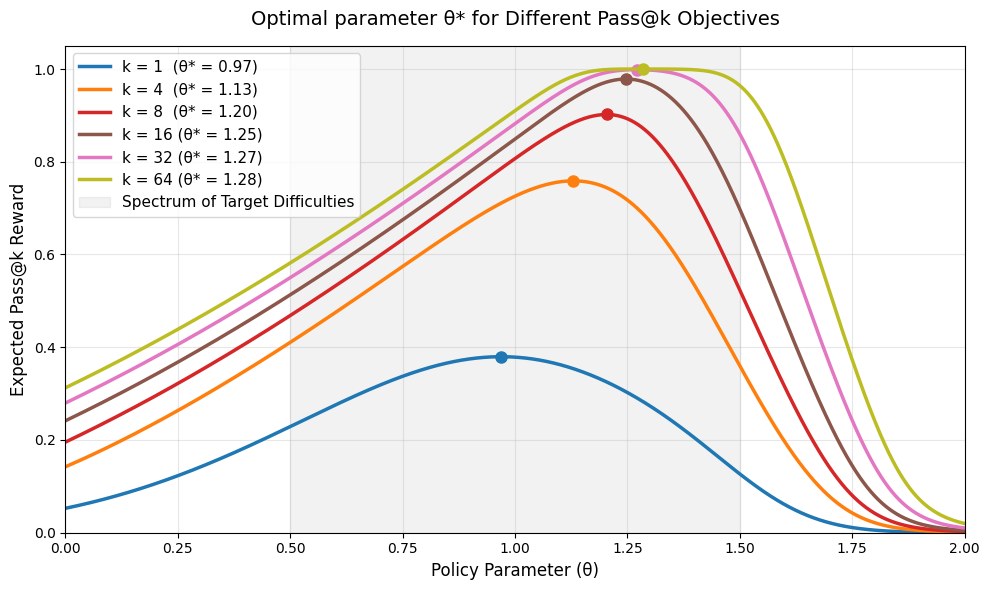

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# =====================================================================
# 1. EMPIRICAL SAMPLING FOR THE CONTINUOUS SPECTRUM
# =====================================================================

SIGMA = 0.2
THETA_INIT = 0.2
# State X has shape (n, X_DIM): col 0 is difficulty u ~ U(0.5,1.5); extra cols are random covariates.
# Reward / Z / P_success depend only on u (scalar policy θ multiplies u).
X_DIM = 64  # change here; re-run nets cell so in_features=X_DIM matches

def sample_data(n_problems, n_generations, sigma=SIGMA, theta_init=THETA_INIT):
    if X_DIM < 1:
        raise ValueError("X_DIM must be >= 1")
    x0 = np.random.uniform(0.5, 1.5, n_problems)
    if X_DIM == 1:
        X = x0.reshape(-1, 1)
    else:
        extras = np.random.standard_normal((n_problems, X_DIM - 1))
        X = np.column_stack([x0, extras])
    W = 0.07 - 0.04 * x0
    Z = np.random.normal(loc=theta_init * x0[:, None], scale=sigma, size=(n_problems, n_generations))
    X_col = x0[:, np.newaxis]
    W_col = W[:, np.newaxis]
    tolerance = np.sqrt(W_col)
    Y = (np.abs(Z - X_col**2) <= tolerance).astype(float)

    mu = theta_init * x0
    L = x0**2 - np.sqrt(W)
    U = x0**2 + np.sqrt(W)
    cdf_upper = norm.cdf(U, loc=mu, scale=sigma)
    cdf_lower = norm.cdf(L, loc=mu, scale=sigma)
    P_success = cdf_upper - cdf_lower

    score = ((Z - theta_init * x0[:, None]) * x0[:, None]) / sigma**2

    # Oracle centered at 0-mean
    P_success = P_success[:, None]
    true_v_k_minus_1 = 1.0 - (1.0 - P_success)**(k - 1)
    true_v_k = 1.0 - (1.0 - P_success)**k
    true_adv = np.maximum(true_v_k_minus_1, Y) - true_v_k
    return X, Z, Y, P_success, true_adv, score


def compute_analytical_curves(thetas, k_values, sigma=0.2):
    """
    Computes the EXACT expected Pass@k using the closed-form Normal CDF.
    No Monte Carlo sampling required. Averages only over task difficulty u in [0.5, 1.5];
    extra state dimensions in ``sample_data`` do not affect P(success|u) under this model.
    """
    X = np.linspace(0.5, 1.5, 1000) 
    W = 0.07 - 0.04 * X
    
    expected_rewards = {k: np.zeros(len(thetas)) for k in k_values}
    
    # Calculate the fixed target bounds for all X
    L = X**2 - np.sqrt(W)
    U = X**2 + np.sqrt(W)
    
    for i, theta in enumerate(thetas):
        # The mean of the policy for all X
        mu = theta * X
        
        # Calculate exactly how much of the Normal distribution falls inside [L, U]
        cdf_upper = norm.cdf(U, loc=mu, scale=sigma)
        cdf_lower = norm.cdf(L, loc=mu, scale=sigma)
        P_success = cdf_upper - cdf_lower
        
        # Apply Pass@k and average across the batch of problems
        for k in k_values:
            pass_k_score = 1 - (1 - P_success)**k
            expected_rewards[k][i] = np.mean(pass_k_score)
            
    return expected_rewards

def leave_one_out(Y):
    """
    Y: (m, n)
    Returns: (m, n * (n - 1)) — each row of Y expanded to n rows of length n-1, then raveled.
    """
    m, n = Y.shape
    j = np.arange(n)[:, None]
    k = np.arange(n - 1)[None, :]
    col = np.where(k < j, k, k + 1)
    return Y[:, col].reshape(m * n, n - 1)

# =====================================================================
# 2. COMPUTE THE CURVES
# =====================================================================
thetas = np.linspace(0.0, 2.0, 10000)
k_values = [1, 4, 8, 16, 32, 64] 
k_to_best_theta = {}

# Run the massive Monte Carlo simulation
# results = compute_empirical_curves(thetas, k_values, N=5000)
results = compute_analytical_curves(thetas, k_values, sigma=0.2)

# =====================================================================
# 3. PLOT THE RESULTS
# =====================================================================
plt.figure(figsize=(10, 6))
n_k = len(k_values)
_base_cmap = plt.cm.tab20 if n_k > 10 else plt.cm.tab10
colors = _base_cmap(np.linspace(0, 1, n_k, endpoint=False))

for idx, k in enumerate(k_values):
    rewards = results[k]
    
    # Find the peak
    best_idx = np.argmax(rewards)
    best_theta = thetas[best_idx]
    k_to_best_theta[k] = best_theta
    max_reward = rewards[best_idx]
    
    plt.plot(thetas, rewards, label=f'k = {k:<2} (θ* = {best_theta:.2f})', 
             color=colors[idx], linewidth=2.5)
    
    # Mark the peak
    plt.plot(best_theta, max_reward, marker='o', markersize=8, color=colors[idx])

plt.title("Optimal parameter θ* for Different Pass@k Objectives", 
          fontsize=14, pad=15)
plt.xlabel("Policy Parameter (θ)", fontsize=12)
plt.ylabel("Expected Pass@k Reward", fontsize=12)

plt.axvspan(0.5, 1.5, color='gray', alpha=0.1, label='Spectrum of Target Difficulties')
plt.legend(fontsize=11, loc='upper left')
plt.grid(True, alpha=0.3)
plt.ylim(0, 1.05)
plt.xlim(0.0, 2.0)
plt.tight_layout()

plt.show()

In [2]:
k_to_best_theta

{1: np.float64(0.9692969296929693),
 4: np.float64(1.12991299129913),
 8: np.float64(1.2035203520352036),
 16: np.float64(1.246924692469247),
 32: np.float64(1.271127112711271),
 64: np.float64(1.284928492849285)}

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from typing import Union, Sequence

def _normalize_hidden(hidden: Union[int, Sequence[int]]) -> list:
    if isinstance(hidden, int):
        return [hidden]
    return list(hidden)


def _mlp_layers(
    in_features: int,
    hidden: Union[int, Sequence[int]],
    out_features: int,
) -> nn.Sequential:
    """Linear-ReLU blocks with widths ``hidden`` (single int or list), ending with Linear(out_features)."""
    hids = _normalize_hidden(hidden)
    layers: list = []
    d_in = in_features
    for h in hids:
        layers.extend([nn.Linear(d_in, h), nn.ReLU()])
        d_in = h
    layers.append(nn.Linear(d_in, out_features))
    return nn.Sequential(*layers)


class SuccessProbNet(nn.Module):
    """State x -> P(success | x) in (0, 1); x has shape (batch, in_features)."""

    def __init__(self, hidden: Union[int, Sequence[int]] = 64, in_features: int = 1):
        super().__init__()
        self.net = nn.Sequential(
            _mlp_layers(in_features, hidden, 1),
            nn.Sigmoid(),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x).squeeze(-1)

# =====================================================================
# 1. SETUP THE ENVIRONMENT
# =====================================================================
n_X = 512
n_Z = 4
k = 64
iterations = 500
base_lr = 0.01 

# reward estimator
re_lr = 0.01
hidden = [64]
inner_steps = 10 # Used for the standard estimator
max_cv_steps = 10 # Used for the 5-fold estimator early stopping

success_prob_net = SuccessProbNet(hidden=hidden, in_features=X_DIM).double()
success_prob_opt = torch.optim.Adam(success_prob_net.parameters(), lr=re_lr)

cv_prob_net = SuccessProbNet(hidden=hidden, in_features=X_DIM).double()

# Track the parameter trajectories
thetas = {
    'Unbiased LOO': THETA_INIT,
    'Unbiased LOO': THETA_INIT,
    'Naive': THETA_INIT,
    'Learned Success Prob': THETA_INIT,
}
trajectories = {method: [THETA_INIT] for method in thetas.keys()}

theta_param = {
    m: torch.nn.Parameter(torch.tensor(thetas[m], dtype=torch.float64))
    for m in thetas.keys()
}
optimizers = {
    m: torch.optim.Adam([theta_param[m]], lr=base_lr, maximize=True)
    for m in thetas.keys()
}
track_adv_var = {m: [] for m in thetas.keys()}
track_g_bias = {m: [] for m in thetas.keys()}
track_g_mse = {m: [] for m in thetas.keys()}
# Optional: Tracker for the variance of the estimator itself
track_g_variance = {m: [] for m in thetas.keys()}

print("Starting PyTorch Adam (on-policy, manual grad g; separate optimizer per method)...")

# =====================================================================
# 2. THE TRAINING LOOP
# =====================================================================
for t in range(1, iterations + 1):
    for method in thetas.keys():
        current_theta = theta_param[method].detach().item()
        X, Z, Y, p_success, true_adv, score = sample_data(n_X, n_Z, theta_init=current_theta)

        # 3. COMPUTE ADVANTAGE
        if method == 'Unbiased LOO':
            X, Z, Y, p_success, true_adv, score = sample_data(n_X, k, theta_init=current_theta)
            p_ub = np.max(Y, axis=1, keepdims=True)
            sum_others = np.sum(Y, axis=1, keepdims=True) - Y
            loo_baseline = (sum_others > 0).astype(float)
            adv = p_ub - loo_baseline

        elif method == 'Naive':
            # 1. Calculate the naive empirical probability
            p_hat = Y.mean(axis=1, keepdims=True) 

            # 2. Compute the k-1 and k baselines based on p_hat
            v_k_minus_1 = 1.0 - (1.0 - p_hat) ** (k - 1)
            v_k = 1.0 - (1.0 - p_hat) ** k
            
            # 3. Simulated Reward: Max of (others, current specific action Y)
            p_row = np.maximum(v_k_minus_1, Y)
            
            # 4. Zero-Mean Advantage
            adv = p_row - v_k

        elif method == 'Learned Success Prob':
            x_t = torch.as_tensor(X, dtype=torch.float64)  
            s_t = torch.as_tensor(Y.sum(axis=1), dtype=torch.float64)
            n_t = float(n_Z)
            success_prob_net.train()
            for _ in range(inner_steps):
                success_prob_opt.zero_grad(set_to_none=True)
                p_hat = success_prob_net(x_t).clamp(1e-7, 1.0 - 1e-7)
                nll = -(s_t * torch.log(p_hat) + (n_t - s_t) * torch.log(1.0 - p_hat)).mean()
                nll.backward()
                success_prob_opt.step()
            success_prob_net.eval()
            with torch.no_grad():
                p_learned = success_prob_net(x_t).clamp(1e-7, 1.0 - 1e-7).detach().cpu().numpy()
            
            # Expand p_learned to (n_X, 1) to broadcast correctly against Y (n_X, n_Z)
            p = p_learned[:, None] if p_learned.ndim == 1 else p_learned

            # The collapsed Rao-Blackwellized Advantage
            # adv = ((1.0 - p) ** (k - 1)) * (Y - Y.mean(axis=1, keepdims=True))
            adv = ((1.0 - p) ** (k - 1)) * (Y - p)
            # 2. Calculate the cross-sample baseline (Leave-One-Out Mean)
            # Y_sum = Y.sum(axis=1, keepdims=True)
            # Y_bar_minus_i = (Y_sum - Y) / (n_Z - 1)

            # # 3. The Doubly Robust, Variance-Scaled Advantage
            # adv = ((1.0 - p) ** (k - 1)) * (Y - Y_bar_minus_i)

        else:
            raise ValueError(f"Unknown method: {method!r}")


        # =====================================================================
        # NEW: STANDARDIZE ADVANTAGES & COMPUTE GRADIENTS
        # =====================================================================
        
        # 1. Standardize the Estimator Advantage
        g = np.mean(adv * score)

        # 2. Standardize the Oracle Advantage (Apples-to-Apples comparison)
        g_oracle = np.mean(true_adv * score)

        # 4. PyTorch Adam Update (maximization); g is numpy from REINFORCE
        p = theta_param[method]
        optimizers[method].zero_grad(set_to_none=True)
        p.grad = torch.as_tensor(g, dtype=p.dtype, device=p.device)
        optimizers[method].step()
        thetas[method] = p.item()
        trajectories[method].append(thetas[method])

        # -----------------------------------------------------------------
        # LOG INTERNAL METRICS
        # -----------------------------------------------------------------
        
        # 1. Calculate the component gradients for the entire batch USING NORMALIZED ADVANTAGES
        per_sample_g_hat = adv * score
        per_sample_g_oracle = true_adv * score
        
        # 2. Component error array
        per_sample_error = per_sample_g_hat - per_sample_g_oracle
        
        # 3. Identity Metrics
        batch_bias = np.mean(per_sample_error)
        batch_mse = np.mean(per_sample_error**2)
        
        # 4. True Variance of the Estimator (divided by the total number of items in the mean)
        # estimator_variance = np.var(per_sample_g_hat) / per_sample_g_hat.size
        # estimator_variance = np.var(per_sample_g_hat)
        estimator_variance = np.var(per_sample_error)
        
        track_g_bias[method].append(float(batch_bias))
        track_g_mse[method].append(float(batch_mse))
        track_g_variance[method].append(float(estimator_variance))

print(f"Final Thetas:")
for m, vals in trajectories.items():
    print(f"  {m}: {vals[-1]:.4f}")
print(f"Optimal Theta: {k_to_best_theta[k]:.4f}") # Uncomment if k_to_best_theta is available

Starting PyTorch Adam (on-policy, manual grad g; separate optimizer per method)...
Final Thetas:
  Unbiased LOO: 1.2757
  Naive: 0.9961
  Learned Success Prob: 1.2688
Optimal Theta: 1.2849


In [4]:
print(f"Optimal Theta: {k_to_best_theta[k]:.4f}") # Uncomment if k_to_best_theta is available

Optimal Theta: 1.2849


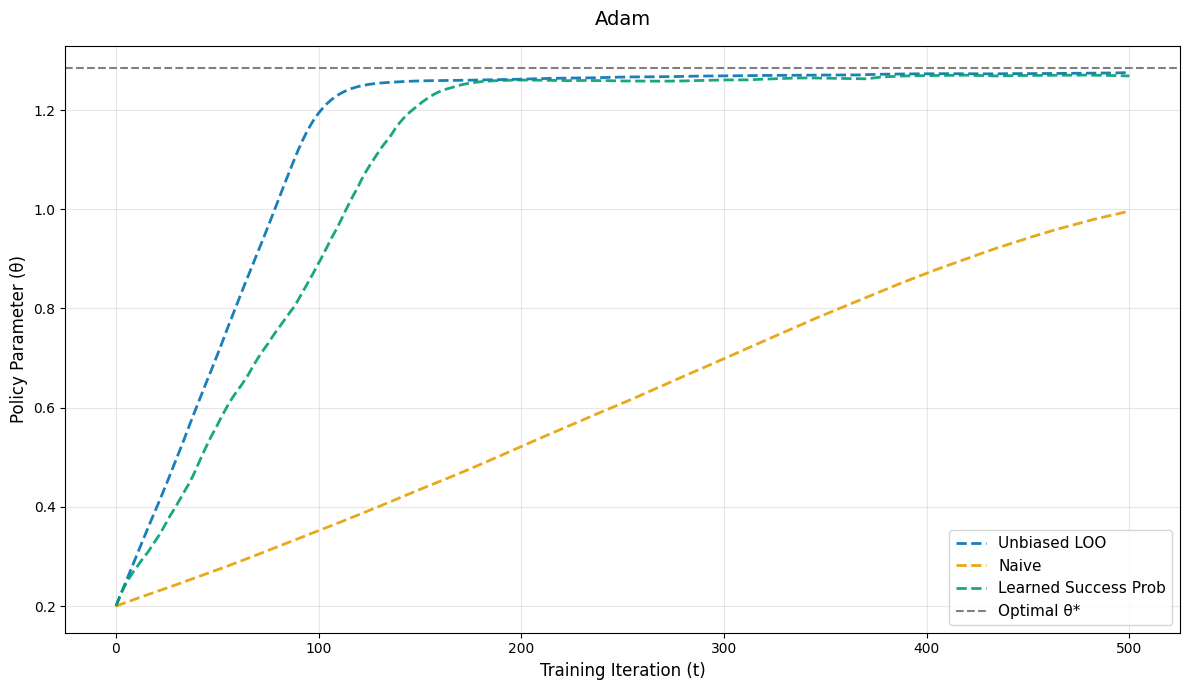

In [5]:

# =====================================================================
# 3. PLOT THE LEARNING CURVES
# =====================================================================
# Okabe-Ito-style palette: colorblind-safe, spaced across hues (not the earlier `colors` from pass@k curves)
_line_colors = [
    "#0072B2",  # blue
    "#E69F00",  # orange
    "#009E73",  # bluish green
    "#CC79A7",  # red-purple
    "#D55E00",  # vermillion
    "#56B4E9",  # sky blue
    "#000000",  # black
    "#F0E442",  # yellow
    "#A65628",  # brown
]
plt.figure(figsize=(12, 7))

for idx, method in enumerate(thetas.keys()):
    plt.plot(trajectories[method], label=method, alpha=0.9, color=_line_colors[idx], linewidth=2, linestyle='--')

plt.title("Adam", fontsize=14, pad=15)
plt.xlabel("Training Iteration (t)", fontsize=12)
plt.ylabel("Policy Parameter (θ)", fontsize=12)
# plt.ylim(0.8, 1.5)
plt.axhline(k_to_best_theta[k], color='gray', linestyle='--', label='Optimal θ*')

plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

KeyboardInterrupt: 

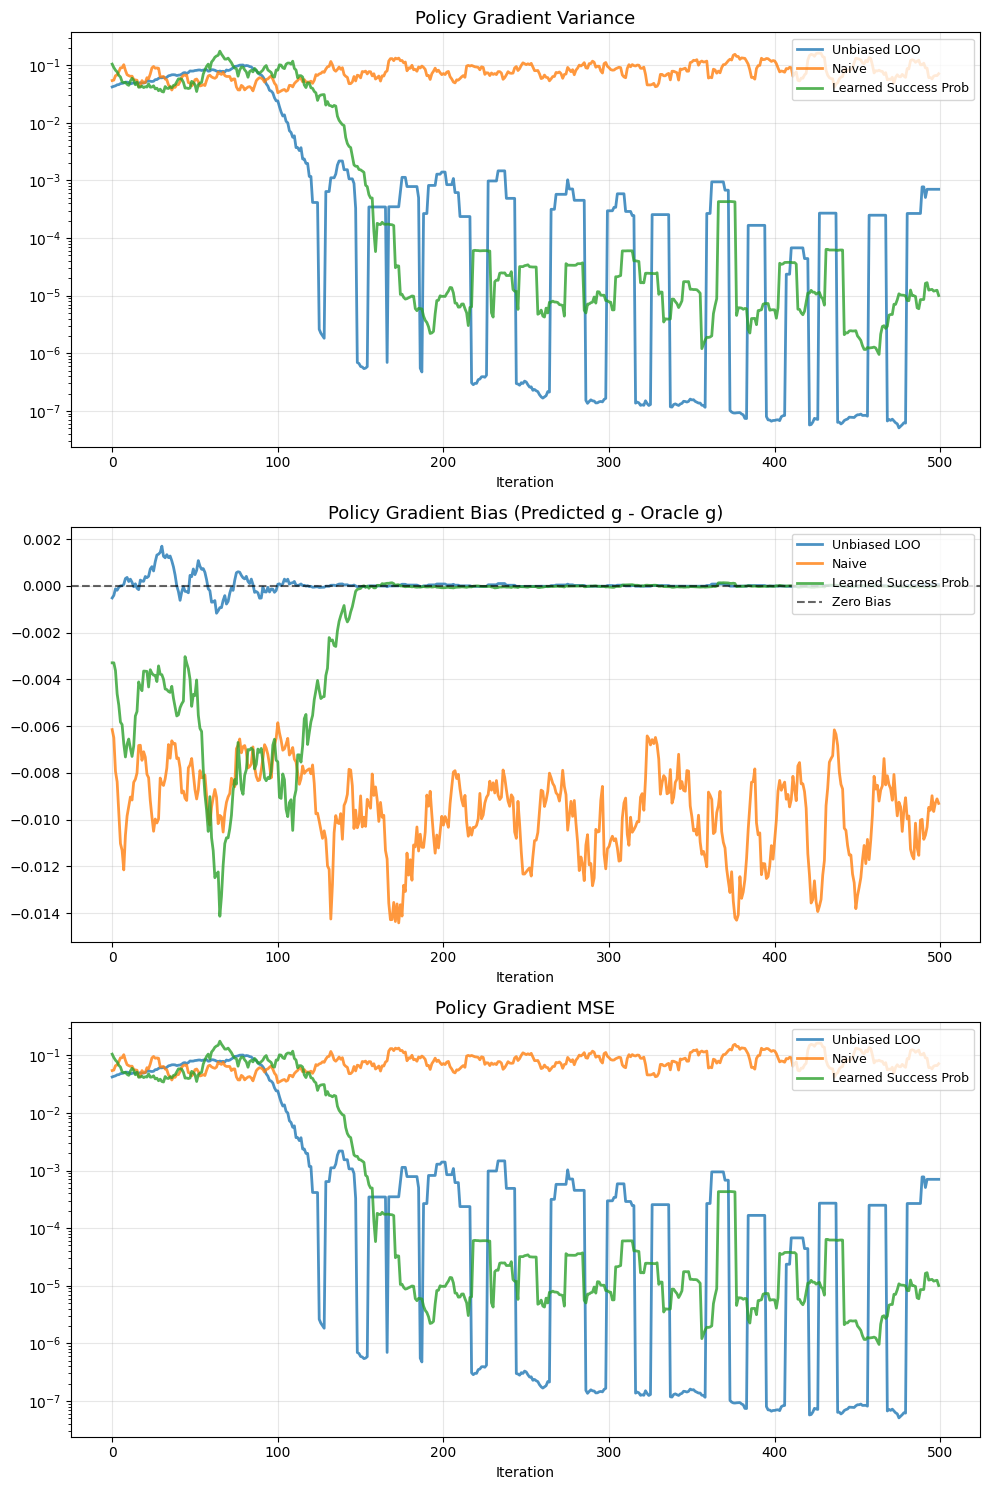

In [6]:
# =====================================================================
# 5. VISUALIZE AND PRINT INTERNAL METRICS
# =====================================================================
METRIC_SMOOTH_WINDOW = 10  # centered moving average; use 1 for raw trajectories

def _smooth_1d(y, window):
    y = np.asarray(y, dtype=float)
    w = int(window)
    if w <= 1 or len(y) < 3:
        return y
    if w % 2 == 0:
        w += 1
    pad = w // 2
    ypad = np.pad(y, (pad, pad), mode="edge")
    kernel = np.ones(w, dtype=float) / w
    return np.convolve(ypad, kernel, mode="valid")

fig, axes = plt.subplots(3, 1, figsize=(10, 15))

# Plot 1: Gradient Variance
for m, vals in track_g_variance.items():
    axes[0].plot(_smooth_1d(vals, METRIC_SMOOTH_WINDOW), label=m, linewidth=2, alpha=0.8)
axes[0].set_title("Policy Gradient Variance", fontsize=13)
axes[0].set_yscale('log') # Log scale because LOO variance explodes
axes[0].set_xlabel("Iteration")
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=9, loc='upper right')

# Plot 2: Gradient Bias
for m, vals in track_g_bias.items():
    axes[1].plot(_smooth_1d(vals, METRIC_SMOOTH_WINDOW), label=m, linewidth=2, alpha=0.8)
axes[1].axhline(0, color='black', linestyle='--', alpha=0.6, label='Zero Bias') # Added reference line
axes[1].set_title("Policy Gradient Bias (Predicted g - Oracle g)", fontsize=13)
axes[1].set_xlabel("Iteration")
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=9, loc='upper right')

# Plot 3: Gradient MSE
for m, vals in track_g_mse.items():
    axes[2].plot(_smooth_1d(vals, METRIC_SMOOTH_WINDOW), label=m, linewidth=2, alpha=0.8)
axes[2].set_title("Policy Gradient MSE", fontsize=13)
axes[2].set_yscale('log') # CRITICAL: Log scale required here too!
axes[2].set_xlabel("Iteration")
axes[2].grid(True, alpha=0.3)
axes[2].legend(fontsize=9, loc='upper right')

plt.tight_layout()
plt.savefig('variance.png')
plt.show()


# =====================================================================
# 6. PRINT SUMMARY FOR LLM CONTEXT
# =====================================================================
print("\n" + "="*65)
print("METRICS SUMMARY (Average of final 100 iterations)")
print("="*65)

# Helper function to print nicely formatted blocks
def print_metric_block(title, tracking_dict):
    print(f"\n--- {title} ---")
    for m, vals in tracking_dict.items():
        if len(vals) > 0:
            avg_val = np.mean(vals[-100:])
            print(f"  {m:<40}: {avg_val:.6f}")

print_metric_block("Policy Gradient Variance", track_g_variance)
print_metric_block("Policy Gradient Bias", track_g_bias)
print_metric_block("Policy Gradient MSE", track_g_mse)
print_metric_block("Advantage Variance (Proxy)", track_adv_var)

In [ ]:
np.array(track_g_bias['Naive'])**2 + np.array(track_g_variance['Naive'])


array([1.09931341e-01, 1.44294988e-02, 1.06622935e-01, 1.72794992e-02,
       5.06305013e-02, 4.31420441e-02, 1.47740380e-01, 2.21555037e-03,
       1.38139887e-03, 1.55023920e-01, 6.34473165e-02, 5.97630842e-03,
       9.01055760e-02, 8.44842211e-03, 5.77257493e-04, 1.36148715e-02,
       4.98663341e-02, 5.04789387e-03, 8.35281810e-03, 9.82173928e-02,
       1.05528886e-01, 7.75155800e-02, 4.41567191e-03, 2.59973320e-02,
       7.29513879e-02, 1.40041510e-03, 4.09249268e-02, 9.20143134e-04,
       2.71851220e-03, 3.14309254e-02, 9.99282896e-03, 5.89326874e-04,
       1.42472204e-01, 1.84007524e-01, 1.04215392e-01, 8.91497797e-02,
       6.85588895e-02, 1.42870333e-01, 6.22944072e-02, 5.65410099e-03,
       8.43760681e-02, 2.38243410e-02, 7.59596987e-02, 4.09820305e-02,
       1.45965375e-02, 2.32504395e-02, 9.15336385e-02, 8.46530650e-02,
       1.97556607e-02, 5.37472578e-02, 1.96166467e-01, 2.73367245e-01,
       2.99538568e-01, 5.66079625e-02, 4.01601319e-02, 1.47794015e-02,
      

In [ ]:
np.array(track_g_mse['Naive'])

array([1.09931341e-01, 1.44294988e-02, 1.06622935e-01, 1.72794992e-02,
       5.06305013e-02, 4.31420441e-02, 1.47740380e-01, 2.21555037e-03,
       1.38139887e-03, 1.55023920e-01, 6.34473165e-02, 5.97630842e-03,
       9.01055760e-02, 8.44842211e-03, 5.77257493e-04, 1.36148715e-02,
       4.98663341e-02, 5.04789387e-03, 8.35281810e-03, 9.82173928e-02,
       1.05528886e-01, 7.75155800e-02, 4.41567191e-03, 2.59973320e-02,
       7.29513879e-02, 1.40041510e-03, 4.09249268e-02, 9.20143134e-04,
       2.71851220e-03, 3.14309254e-02, 9.99282896e-03, 5.89326874e-04,
       1.42472204e-01, 1.84007524e-01, 1.04215392e-01, 8.91497797e-02,
       6.85588895e-02, 1.42870333e-01, 6.22944072e-02, 5.65410099e-03,
       8.43760681e-02, 2.38243410e-02, 7.59596987e-02, 4.09820305e-02,
       1.45965375e-02, 2.32504395e-02, 9.15336385e-02, 8.46530650e-02,
       1.97556607e-02, 5.37472578e-02, 1.96166467e-01, 2.73367245e-01,
       2.99538568e-01, 5.66079625e-02, 4.01601319e-02, 1.47794015e-02,
      